# Ricerca di Trading System

Serve a **scoprire se un segnale di ingresso ha un vantaggio reale**, separando entry, uscita e "quando sto fermo" — cercarli insieme confonde quale dei tre sta davvero funzionando.

Si legge dall'alto in basso, senza celle facoltative: ogni sezione usa il risultato di quella prima.

**Ordine:** la Sessione 1 misura il segnale puro (nessun capitale, nessuna posizione). La Sessione 2 sceglie come uscirne e diventa un sistema vero, con trade e costi.

In [ ]:
!pip install -q TA-Lib backtesting

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.8/190.8 kB 8.5 MB/s eta 0:00:00


### Sezione 0 · Preparazione

Clona la repo e prepara l'ambiente. Va eseguita una volta sola a inizio sessione Colab.

In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import sys
from pathlib import Path
from google.colab import userdata
import shutil
# Salva il token una volta in Colab: icona chiave a sinistra → "Secrets" → aggiungi GITHUB_TOKEN
# Assicurati che il nome del secret sia 'GITHUB_TOKEN' (o quello che preferisci) e non il token stesso.
GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')

REPO_DIR = Path('/content/Trading-System-Creator_V4')
if REPO_DIR.exists():
    shutil.rmtree(REPO_DIR)  # ripulisce il tentativo fallito precedente

!git clone https://{GITHUB_TOKEN}@github.com/matti410/Trading-System-Creator_V4.git

%cd Trading-System-Creator_V4

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

Cloning into 'Trading-System-Creator_V4'...
remote: Enumerating objects: 141, done.
remote: Counting objects: 100% (141/141), done.
remote: Compressing objects: 100% (141/141), done.
remote: Total 141 (delta 67), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (141/141), 1.60 MiB | 2.79 MiB/s, done.
Resolving deltas: 100% (67/67), done.
/content/Trading-System-Creator_V4


In [ ]:
import datetime as dt
from dateutil.relativedelta import relativedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import talib as ta

import entry_long, entry_short
import exit_long, exit_short
import engine as eng
from engine.vwap_ops import vwap_anchored_daily
import engine.event_study
import engine.splitting
from engine.exit_search_bt import run_exit_search_bt
import filter_conditions, vwap_regime_filter_conditions
from engine.filter_search_bt import run_filter_search_bt
from engine.due_meta import due_meta
from engine.equity_plot import plot_equity

/usr/local/lib/python3.13/dist-packages/backtesting/_plotting.py:55: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support, such as old IDEs. Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


## Sezione 1 · I dati

Scarica le candele da MetaTrader 5.

**Parametri che puoi cambiare:** strumento, timeframe, periodo storico.

In [ ]:
symbol    = "EURUSD"
timeframe = 'M15'
FREQ      = "15min"      # come pandas scrive il timeframe: "15min", "h", "D"

df = pd.read_csv('EURUSD_M15.csv', index_col='Date')
df.index = pd.to_datetime(df.index, utc=True)

print(f"{symbol} {timeframe} — {len(df):,} barre  ·  da {df.index[0]}  a  {df.index[-1]}")
df.tail(3)

EURUSD M15 — 91,596 barre  ·  da 2023-01-02 00:00:00+00:00  a  2026-09-07 06:45:00+00:00


,Open,High,Low,Close,Volume
Date,,,,,
2026-09-07 06:15:00+00:00,1.16095,1.16121,1.16092,1.16119,232
2026-09-07 06:30:00+00:00,1.16119,1.16121,1.16089,1.16095,341
2026-09-07 06:45:00+00:00,1.16095,1.16117,1.16090,1.16117,270


## Sezione 2 · Gli indicatori

Le condizioni di ingresso (`entry_long.py`, `entry_short.py`) non calcolano niente da sole: leggono colonne già pronte in questa tabella. Qui le costruiamo.

| Colonna | Cos'è | Chi la usa |
|---|---|---|
| `rsi` | oscillatore 0-100: sotto 30 il prezzo è "sceso troppo", sopra 70 "salito troppo" | l'entry mean reversion |
| `ema20`, `ema50` | medie mobili veloce e lenta | l'entry di controllo |
| `zlema50` | media mobile a ritardo ridotto | l'entry di trend |
| `atr`, `realized_vol` | quanto si muove il prezzo di solito | dimensionamento futuro |
| `vwap` | prezzo medio della giornata pesato per volume | i filtri di contesto |

Sulla **zero-lag EMA**: una media normale è sempre in ritardo; la ZLEMA lo compensa proiettando in avanti il prezzo, ma esagera i movimenti e genera più falsi attraversamenti — su M15 va bene (più campioni), ma è dove i costi di transazione pesano di più.

In [ ]:
df["rsi"] = ta.RSI(df["Close"], timeperiod=14)
df['macd'], df['macd_signal'], df['macd_hist'] = ta.MACD(df["Close"], fastperiod=12, slowperiod=26, signalperiod=9)
df["ema20"] = df["Close"].ewm(span=20, min_periods=20).mean()   # ← min_periods
df["ema50"] = df["Close"].ewm(span=50, min_periods=50).mean()   # ← min_periods
def zlema(series, period):
    """Media mobile a ritardo ridotto: proietta il prezzo per compensare il lag."""
    lag = int((period - 1) / 2)
    return (2 * series - series.shift(lag)).ewm(span=period, adjust=False).mean()

df["zlema50"] = zlema(df["Close"], 50)
df["atr"] = ta.ATR(df["High"], df["Low"], df["Close"], timeperiod=14)          # ← ATR vero
df["realized_vol"] = df["Close"].pct_change().rolling(96).std()
df["adx"] = ta.ADX(df["High"], df["Low"], df["Close"], timeperiod=14)          # ← ADX vero
df["vwap"] = vwap_anchored_daily(df)
df.dropna(inplace=True)
print(f"{len(df):,} barre pronte, {df.shape[1]} colonne")
print(f"adx  — min {df['adx'].min():.1f}  mediana {df['adx'].median():.1f}  max {df['adx'].max():.1f}")
print(f"atr  — mediana {df['atr'].median():.6f}  ({df['atr'].median()/df['Close'].median()*100:.3f}% del prezzo)")
df.tail(3)

91,500 barre pronte, 16 colonne
adx  — min 6.0  mediana 22.6  max 74.5
atr  — mediana 0.000572  (0.052% del prezzo)


,Open,High,Low,Close,Volume,rsi,macd,macd_signal,macd_hist,ema20,ema50,zlema50,atr,realized_vol,adx,vwap
Date,,,,,,,,,,,,,,,,
2026-09-07 06:15:00+00:00,1.16095,1.16121,1.16092,1.16119,232,47.213804,-0.000099,-0.000045,-0.000054,1.161270,1.161424,1.161232,0.000294,0.000326,14.596341,1.161405
2026-09-07 06:30:00+00:00,1.16119,1.16121,1.16089,1.16095,341,42.349954,-0.000112,-0.000058,-0.000054,1.161240,1.161405,1.161225,0.000296,0.000325,14.303121,1.161385
2026-09-07 06:45:00+00:00,1.16095,1.16117,1.16090,1.16117,270,47.671587,-0.000103,-0.000067,-0.000036,1.161233,1.161396,1.161245,0.000294,0.000326,14.030846,1.161373


## Sezione 3 · Dividere i dati in due

Questa è la regola più importante del notebook, e l'unica che non si può violare.

- **In-Sample (80%)** — la parte su cui si cerca, si prova, si sbaglia quante volte si vuole
- **Out-of-Sample (20%)** — la parte che **non si guarda fino alla fine**

Perché conta: su mille combinazioni provate, qualcuna sembrerà eccellente per puro caso — è garantito, anche su dati casuali. L'unico modo per accorgersene è tenere da parte dati che nessuna combinazione ha mai visto.

Se la guardi, cambi qualcosa e riguardi, l'Out-of-Sample non esiste più: è diventata parte della ricerca. **Si apre una volta sola, a ricerca in-sample conclusa** (passo 6 di `ROADMAP_RICERCA.md`).

In [ ]:
IS_RATIO = 0.8
df_is, df_oos = eng.splitting.split_is_oos(df, is_ratio=IS_RATIO)
eng.splitting.describe_split(df_is, df_oos)

,n_barre,quota,dal,al
In-Sample,73200,0.8,2023-01-03 00:00:00+00:00,2025-12-10 13:45:00+00:00
Out-of-Sample,18300,0.2,2025-12-10 14:00:00+00:00,2026-09-07 06:45:00+00:00
Totale,91500,1.0,2023-01-03 00:00:00+00:00,2026-09-07 06:45:00+00:00


## Sezione 4 · Features Engineering

Registra tutti i trigger di ingresso ed uscita nel registro condiviso — va fatto prima di qualunque uso di `event_study` o `exit_search_bt`, che leggono le entry da lì.

In [ ]:
entry_long.registra_trigger_long()
entry_short.registra_trigger_short()

exit_long.registra_exit_long()
exit_short.registra_exit_short()

filter_conditions.registra_filtri()
vwap_regime_filter_conditions.registra_filtri_vwap()

[registra_trigger_long] 26 entry long registrate (0 gia' presenti).
[registra_trigger_short] 26 entry short registrate (0 gia' presenti).
[registra_exit_long] 4 exit long registrate (0 gia' presenti).
[registra_exit_short] 4 exit short registrate (0 gia' presenti).
[registra_filtri] 20 filtri registrati (0 gia' presenti).
[registra_filtri_vwap] 5 filtri registrati (0 gia' presenti).


## SESSIONE 1 · L'andamento del prezzo dopo il trigger

Per ogni condizione: tutte le barre in cui è vera, e dove va il prezzo dopo, fino all'orizzonte `H`. Si entra all'apertura della barra successiva al segnale (mai sullo stesso Close che l'ha generato). La curva è sempre "a favore del trade": per una condizione short, sale quando il prezzo scende.

`H` è una scelta, non una griglia: si calcola una volta sola e tutti gli orizzonti più corti si leggono sulla stessa curva.

**Nessuna occorrenza viene scartata**, nemmeno quelle scattate mentre si era già dentro un trade: contano tutte come eventi indipendenti.

## 1.1 · Le curve a confronto

Ogni linea è una condizione, asse orizzontale le barre dal trigger, verticale la variazione media in percentuale. **La linea nera tratteggiata è il mercato** (nessuna condizione): il metro di paragone — sopra di lei la curva aggiunge qualcosa, appiccicata a lei non dice niente.

Guarda la **forma**: sale e prosegue = il movimento continua; sale e si appiattisce = il vantaggio ha una scadenza (è lì l'orizzonte del trade); sale e ridiscende = quello che guadagnavi lo restituisci.

In [ ]:
H = 15
MIN_TRADES = 200

pip = 0.0001 unita' di prezzo  (prezzo medio 1.10)
10 entry scartate sotto min_trades=200
  barra   1/15
  barra   2/15
  barra   3/15
  barra   4/15
  barra   5/15
  barra   6/15
  barra   7/15
  barra   8/15
  barra   9/15
  barra  10/15
  barra  11/15
  barra  12/15
  barra  13/15
  barra  14/15
  barra  15/15

42 entry · orizzonte 15 barre · 96,675 trigger misurati


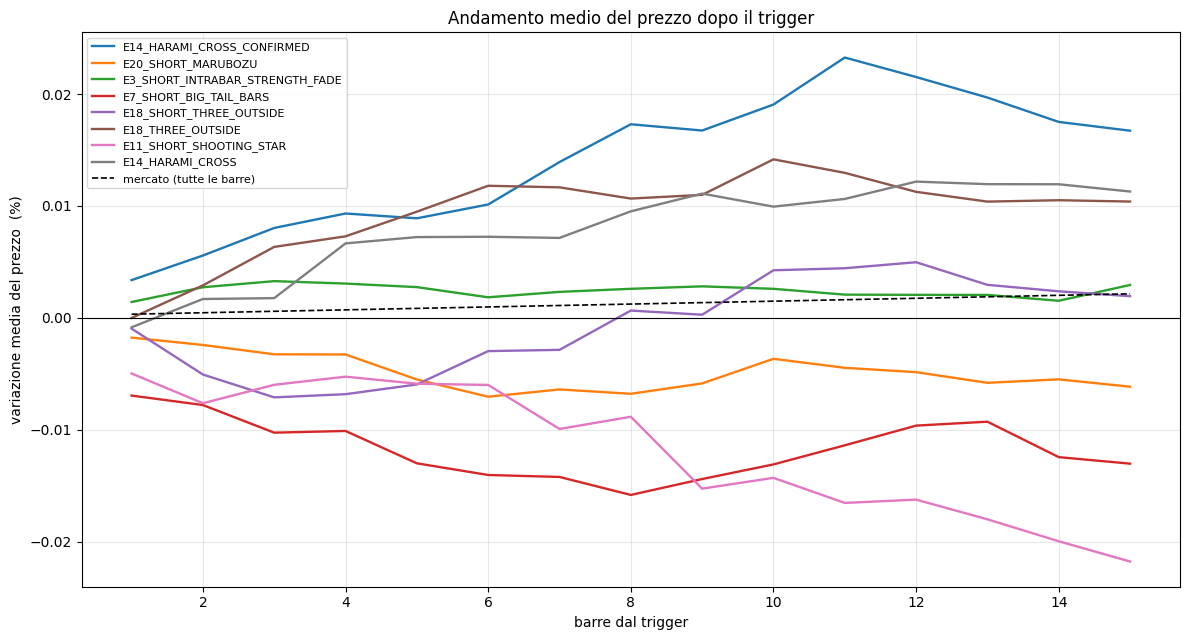

In [ ]:
ev = eng.event_study.run_event_study(df_is, horizon=H, min_trades=MIN_TRADES)
ev.plot()
#ev.plot_singola("E7_BIG_TAIL_BARS", pips=True)

## 1.2 · La sintesi
| colonna | cosa dice |
|---|---|
| `trades` | quante volte la condizione è scattata |
| `barra_picco` / `barra_picco_netto` | dove la curva è più estrema, e dove si stacca di più dal mercato (usato da `diagnosi()`) |
| `picco_pct` / `picco_pips` | il valore a quel picco — **può essere negativo**: non è un errore, è un trade che perde |
| `incertezza_pct` | quanto balla la media a quel punto (errore standard) |
| `volte_incertezza` | picco diviso incertezza — sotto 2 il picco non si distingue dal rumore |
| `a_fine_pct` | dove sta il prezzo a fine orizzonte: più basso del picco = il movimento è rientrato |
| `vs_mercato_pct` | quanto il trigger si stacca dal movimento che il mercato fa comunque — vicino a zero = è il respiro dell'asset, non il segnale |
| `picco_in_coda` | `True` = il picco netto cade nell'ultimo quarto della finestra, segno di deriva casuale |


**Attenzione al segno:** `picco_pct`/`picco_pips` negativo + backtest sullo stesso trigger che perde = coerente, non un bug.

Perché guardare trades anche qui. MIN_TRADES scarta le condizioni sotto soglia, ma non le rende tutte comparabili: due condizioni appena sopra soglia possono avere un picco grande solo per rumore campionario. Questa tabella è ordinata per picco_pips (ampiezza), non per volte_incertezza (solidità) — prima di scegliere un candidato, controlla sempre la colonna trades e volte_incertezza, non solo la posizione in classifica.

In [ ]:
ev.sintesi.round(4).sort_values('picco_pips', ascending=False).head(5)

,candidato,direction,trades,barra_picco,picco_pips,picco_pct,incertezza_pct,volte_incertezza,a_fine_pct,vs_mercato_pct,barra_picco_netto,picco_in_coda
0,E14_HARAMI_CROSS_CONFIRMED,1,463,11,2.5576,0.0233,0.0075,3.0926,0.0167,0.0216,11,False
15,E11_INVERTED_HAMMER,1,200,9,1.6408,0.0150,0.0088,1.7069,0.0138,0.0137,9,False
5,E18_THREE_OUTSIDE,1,636,10,1.5499,0.0142,0.0064,2.2182,0.0104,0.0127,10,False
7,E14_HARAMI_CROSS,1,923,12,1.3372,0.0122,0.0057,2.1522,0.0113,0.0104,12,True
33,E4_SHORT_EMA_CROSS_DOWN,-1,725,15,0.8493,0.0077,0.0075,1.0274,0.0077,0.0099,15,True


### LONG side

In [ ]:
ev.sintesi[ev.sintesi['direction'] == 1][['candidato', 'picco_pips', 'picco_pct']].sort_values('picco_pips', ascending=False).head(6)

,candidato,picco_pips,picco_pct
0,E14_HARAMI_CROSS_CONFIRMED,2.557622,0.023264
15,E11_INVERTED_HAMMER,1.640778,0.015016
5,E18_THREE_OUTSIDE,1.549872,0.014165
7,E14_HARAMI_CROSS,1.337164,0.012176
9,E13_HARAMI_CONFIRMED,0.777768,0.007087
31,E1_RSI_CROSS_OVERSOLD,0.770883,0.007056


### SHORT side

In [ ]:
ev.sintesi[ev.sintesi['direction'] == -1][['candidato', 'picco_pips', 'picco_pct']].sort_values('picco_pips', ascending=False).head(6)

,candidato,picco_pips,picco_pct
33,E4_SHORT_EMA_CROSS_DOWN,0.849345,0.007738
35,E9_SHORT_CLOSING_PATTERN_ONLY_II,0.546133,0.004982
2,E3_SHORT_INTRABAR_STRENGTH_FADE,0.360125,0.003282
40,E10_SHORT_HANGING_MAN,0.272631,0.002483
30,E13_SHORT_HARAMI,-0.352038,-0.003207
22,E21_SHORT_BELT_HOLD,-0.358536,-0.003271


In [ ]:
ev.diagnosi()

orizzonte impostato          : 12 barre
picchi (netti) nell'ultimo quarto: 52% (22/42, oltre la barra 9)
|picco| / incertezza, mediana: 1.59
|picco| / incertezza, massimo: 3.09

I picchi si ammassano in fondo alla finestra: e' il
comportamento di una deriva casuale, non di un segnale.
Prova a rileggere con horizon=4
e guarda se la forma delle curve cambia.


# SESSIONE 2 · Le condizioni di uscita

Fin qui abbiamo **misurato** un segnale: nessun capitale, nessuna posizione, nessun costo. Da adesso costruiamo un **sistema**: si sceglie un ingresso e si cerca il modo di uscirne.

## 2.1 · Come vengono calcolati stop e target

Nessuna soglia scritta a mano: uno stop dello 0.15% è enorme su EURUSD e minuscolo su BTCUSD. Per ogni barra si misura quanto sarebbe andato in rosso e in verde un trade lì aperto e tenuto `n` barre; lo stop del trade che apri ora è il **percentile richiesto di quelle escursioni sulle ultime 500 occorrenze concluse** — si allarga da solo su un asset volatile, si stringe quando il mercato si calma. Il valore si fissa all'apertura e non cambia più.

> **Perché "concluse" e non "partite".** L'escursione di un trade aperto alla barra `i` si conosce solo alla `i+n`. Usare le ultime 500 partite userebbe prezzi futuri per uno stop deciso oggi — la finestra è quindi spostata indietro di `n` barre.

**Leva:** parametro `margin` (default `1.0` = nessuna leva). Con leva più alta il motore chiude forzatamente le posizioni se il margine non basta più, così un test a leva alta non mostra profitti che nella realtà non avresti mai visto perché il conto sarebbe stato azzerato prima.

## 2.2 · La classifica

Una riga per combinazione, ordinata per Sharpe. `combinazione` si legge `L=<entry long> · S=<entry short>` (`—` dove quel lato non ha un ingresso). Filtrate di default le combinazioni sotto `min_trades` — se una combinazione attesa non compare, controlla prima lì.

| colonna | cosa dice |
|---|---|
| `trades` | quante volte la condizione è scattata |
| `pnl_pct` | rendimento totale sul periodo |
| `sharpe` | rendimento rapportato alla sua variabilità — è quello che ordina la tabella |
| `max_dd_pct` | la perdita peggiore dal picco precedente |
| `win_rate_pct` | trade in guadagno — da solo non basta: 70% vincenti con perdite doppie dei guadagni è comunque un sistema perdente |
| `profit_factor` | incasso dei vincenti per ogni euro perso dai perdenti: sotto 1 il sistema perde |
| `avg_trade` | guadagno medio per trade, in pips — il numero da confrontare col costo round-turn |
| `durata_media` / `durata_max` | durata dei trade, in media e nel caso peggiore |

**A cosa serve confrontare le righe:** in una chiamata l'uscita (`n_barre`, `perc_sl`, `perc_tp`) è identica per tutte le combinazioni — la tabella risponde a "quale entry rende di più con QUESTA uscita", non "quale uscita è la migliore". Per confrontare uscite diverse si rilancia la funzione con altri valori e si mettono le tabelle a confronto a mano.

## 2.3 · Backtest con i trigger selezionati

Griglia completa su tutte le entry sopravvissute/selezionate alla Sessione 1.

**TEST 1**

Condizioni di uscita: STOP LOSS, TAKE PROFIT

In [ ]:
es = run_exit_search_bt(df_is, entry_cols_long=["E14_HARAMI_CROSS_CONFIRMED", None],
                        entry_cols_short=["E4_SHORT_EMA_CROSS_DOWN", None],
                        n_barre=H, perc_sl=90.0, perc_tp=0.0,
                        commission=0.0,)
es.top(10)
#es.trades("L=E7_BIG_TAIL_BARS · S=E9_SHORT_CLOSING_PATTERN_ONLY_II")

1 combinazione/i (None, None, *) scartata/e: nessun ingresso.
segnali ignorati per soglia non calcolabile — E14_HARAMI_CROSS_CONFIRMED: 5, E4_SHORT_EMA_CROSS_DOWN: 3


Backtest.run:   0%|          | 0/73199 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/73199 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/73199 [00:00<?, ?bar/s]

3 combinazioni · n_barre=15 · coppie di uscita: ['—'] · stop adattivo 90.0°/0.0° pct (finestra 500) · spread 0.00000 · commission 0.00000 · margin 1.0


,combinazione,trades,pnl_pct,sharpe,max_dd_pct,win_rate_pct,profit_factor,avg_trade,durata_media,durata_max
0,L=E14_HARAMI_CROSS_CONFIRMED · S=— | X=—,421,6.896,1.084,-1.816,54.157,1.323,1.744,14.397,15
1,L=E14_HARAMI_CROSS_CONFIRMED · S=E4_SHORT_EMA_...,995,9.741,0.904,-3.372,51.457,1.166,1.041,14.320,15
2,L=— · S=E4_SHORT_EMA_CROSS_DOWN | X=—,673,4.275,0.484,-3.410,49.480,1.101,0.706,14.204,15


**TEST 2**

Condizioni di uscita: STOP LOSS, TAKE PROFIT, Regole meccaniche

In [ ]:
es = run_exit_search_bt(df_is,
                        entry_cols_long=["E14_HARAMI_CROSS_CONFIRMED"],
                        entry_cols_short=["E4_SHORT_EMA_CROSS_DOWN"],
                        n_barre=H,
                        exit_rule_pairs=["RSI_EXTREME", "MACD_CROSS",
                                         "EMA_CROSS", None],
                        perc_sl=90.0, perc_tp=0.0, commission=0,
                        min_trades=30,)
es.top(10)

segnali ignorati per soglia non calcolabile — E14_HARAMI_CROSS_CONFIRMED: 5, E4_SHORT_EMA_CROSS_DOWN: 3


Backtest.run:   0%|          | 0/73199 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/73199 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/73199 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/73199 [00:00<?, ?bar/s]

4 combinazioni · n_barre=15 · coppie di uscita: ['RSI_EXTREME', 'MACD_CROSS', 'EMA_CROSS', '—'] · stop adattivo 90.0°/0.0° pct (finestra 500) · spread 0.00000 · commission 0.00000 · margin 1.0


,combinazione,trades,pnl_pct,sharpe,max_dd_pct,win_rate_pct,profit_factor,avg_trade,durata_media,durata_max
0,L=E14_HARAMI_CROSS_CONFIRMED · S=E4_SHORT_EMA_...,1013,10.541,1.149,-4.020,56.663,1.201,1.099,11.500,15
1,L=E14_HARAMI_CROSS_CONFIRMED · S=E4_SHORT_EMA_...,995,9.741,0.904,-3.372,51.457,1.166,1.041,14.320,15
2,L=E14_HARAMI_CROSS_CONFIRMED · S=E4_SHORT_EMA_...,1056,7.156,0.762,-3.427,47.917,1.138,0.730,10.710,15
3,L=E14_HARAMI_CROSS_CONFIRMED · S=E4_SHORT_EMA_...,1098,1.434,0.173,-4.189,37.523,1.033,0.143,7.842,15


In [ ]:
es.top(10).iloc[1]['combinazione']


'L=E14_HARAMI_CROSS_CONFIRMED · S=E4_SHORT_EMA_CROSS_DOWN | X=—'

# SESSIONE 3 · I filtri (pipeline Trend Following)

Entry, uscita e orizzonte restano quelli scelti finora — **congelati**. Qui
si cerca solo il contesto di mercato in cui lo stesso setup rende di più:
un filtro alla volta, mai in combinazione, sempre confrontato con la riga
senza filtro (baseline), mai guardato in valore assoluto.

**Come si applica un filtro:** la sua `direction` decide il lato. Neutro
(`0`) va in AND su entrambi gli ingressi; `+1` solo sul long; `−1` solo sul
short — l'altro lato resta con l'ingresso non filtrato da quel filtro, per
confrontare a parità di condizioni. Pipeline **Trend Following**: la
`direction` del filtro conferma quella dell'entry, non la contraddice (la
pipeline Mean Reverting, quando riparte, la rovescia — vedi
`ROADMAP_RICERCA.md`, Passo 5).

## 3.1 · La classifica

Una riga di baseline (nessun filtro) + una riga per filtro, ordinata per
`guadagno_sharpe` — quanto il filtro aggiunge rispetto alla baseline, non
il valore assoluto del sistema filtrato (Difesa A, Passo 5). Filtrate di
default le righe sotto `min_trades` — la baseline resta sempre visibile.

| colonna | cosa dice |
|---|---|
| `direction` | +1/−1/0, il lato su cui il filtro è stato applicato |
| `trades` | quante volte è scattato l'ingresso con quel filtro attivo |
| `sharpe` | valore assoluto del sistema filtrato — non è la colonna su cui decidere |
| `guadagno_sharpe` | **la colonna che decide**: sharpe del filtro meno sharpe della baseline |
| `avg_trade` / `guadagno_avg_trade` | guadagno medio per trade in pips, e quanto cambia rispetto alla baseline |
| `max_dd_pct` / `win_rate_pct` / `profit_factor` | come nella Sessione 2 |
| `pochi_trade` | `True` sotto `min_trades` — riga esclusa da `.top()` a meno di `solo_valide=False` |

**Un `guadagno_sharpe` positivo ma con pochi trade non è ancora una
scoperta** — è un candidato per il passo successivo.

In [ ]:
filtri_da_provare = (eng.registry.list_filters(0) +
                     eng.registry.list_filters(1) +
                     eng.registry.list_filters(-1))

In [ ]:
fs = run_filter_search_bt(
    df_is,
    entry_long="E14_HARAMI_CROSS_CONFIRMED",
    entry_short="E4_SHORT_EMA_CROSS_DOWN",
    exit_rule_pair=None,
    n_barre=H,
    filtri=filtri_da_provare,
    perc_sl=90.0, perc_tp=0.0, commission=0.00007, min_trades=30,
)
fs.top(15)

Backtest.run:   0%|          | 0/73199 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/73199 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/73199 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/73199 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/73199 [00:00<?, ?bar/s]

...

Backtest.run:   0%|          | 0/73199 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/73199 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/73199 [00:00<?, ?bar/s]

18 righe (baseline + 17 filtri/coppie) · n_barre=15 · exit_rule_pair=— · stop adattivo 90.0°/0.0° pct (finestra 500) · spread 0.00000 · commission 0.00007 · margin 1.0


,filtro,filtro_long,filtro_short,trades,pnl_pct,sharpe,guadagno_sharpe,avg_trade,guadagno_avg_trade,max_dd_pct,win_rate_pct,profit_factor,durata_media,durata_max
0,VWAP_SESSION_CLOSE,VWAP_PREVIOUS_SESSION_CLOSED_ABOVE,VWAP_PREVIOUS_SESSION_CLOSED_BELOW,500,5.220,0.709,1.169,2.690,1.648,-3.561,48.400,1.178,14.282,15
1,F14_LOW_DRIFT_REGIME,F14_LOW_DRIFT_REGIME,F14_LOW_DRIFT_REGIME,337,1.141,0.201,0.660,1.926,0.885,-3.228,49.258,1.062,14.228,15
2,TREND_CONVICTION,F10_TREND_CONVICTION_UP,F11_TREND_CONVICTION_DOWN,399,-0.555,-0.086,0.374,1.447,0.406,-3.762,47.118,0.981,14.286,15
3,F1_ADX_ABOVE,F1_ADX_ABOVE,F1_ADX_ABOVE,526,-0.885,-0.114,0.346,1.369,0.328,-4.352,49.049,0.977,14.232,15
4,F2_ATR_ABOVE,F2_ATR_ABOVE,F2_ATR_ABOVE,507,-0.905,-0.114,0.345,1.354,0.313,-4.886,48.126,0.978,14.079,15
5,VWAP_FAIR_VALUE,VWAP_PRICE_ABOVE_FAIR_VALUE,VWAP_PRICE_BELOW_FAIR_VALUE,515,-2.507,-0.368,0.092,1.020,-0.021,-5.361,44.466,0.921,14.458,15
6,F7_VOLUME_CLIMAX,F7_VOLUME_CLIMAX,F7_VOLUME_CLIMAX,268,-2.743,-0.431,0.029,0.456,-0.586,-5.372,45.896,0.881,13.582,15
7,— baseline —,—,—,995,-4.528,-0.460,0.000,1.041,0.000,-7.750,45.829,0.930,14.320,15
8,MACD_SIGNAL,F4_MACD_ABOVE_SIGNAL,F4_MACD_BELOW_SIGNAL,802,-4.644,-0.528,-0.068,0.907,-0.135,-6.471,46.010,0.913,14.273,15
9,VWAP_GAP_WIDENING,VWAP_GAP_WIDENING,VWAP_GAP_WIDENING,248,-2.725,-0.628,-0.169,0.313,-0.728,-3.820,50.806,0.817,14.266,15


## 3.2 · `due_meta`

Sul filtro (o sui 2-3 filtri) con `guadagno_sharpe` più alto sopra
`min_trades`, si spacca l'In-Sample in due metà e si verifica che il
guadagno regga su entrambe (Difesa C, Passo 5) — un filtro che funziona
solo sulla prima metà è rumore, non edge.

**Entry, uscita e orizzonte non si ripassano: si leggono da `fs`.**
`due_meta` non prende `entry_long`/`entry_short`/`exit_rule_pair`/
`n_barre`/`min_trades` come argomenti — li rilegge direttamente da `fs`
(lo stesso già costruito sopra). Il setup verificato qui è quindi per
costruzione lo stesso che `fs.top()` ha già mostrato: non è possibile
testare per errore un setup diverso.

**Il resto invece va ripassato identico alla cella che ha costruito
`fs`:** `perc_sl`, `perc_tp`, `finestra`, `lag`, `spread`, `commission`,
`cash`, `margin` — non sono salvati su `fs`, quindi vanno riscritti a
mano uguali a sopra.

`n_barre` resta comunque controllato contro `H`: se `fs` è stato
costruito con un `H` diverso da quello attuale in cima al notebook
(setup cambiato, `fs` non ricostruito), la cella si ferma con un errore
invece di verificare in silenzio un `fs` ormai vecchio.

**Come si legge `dm.tabella`:** una riga per etichetta (più la baseline
se `None` è tra le `etichette`), con `pnl_pct_metà1`/`_metà2` (return % assoluto), `sharpe_metà1`/`_metà2`
(assoluto), `guadagno_sharpe_metà1`/`_metà2` (sopra la baseline) e
`trades_metà1`/`_metà2` affiancati, e una colonna `verdetto`:

- `regge` — guadagno positivo in entrambe le metà, campione non corto
- `giudizio sospeso` — guadagno positivo in entrambe, ma almeno una metà
  ha pochi trade: non c'è abbastanza campione per fidarsi
- `non regge` — il guadagno non si ripete, o peggiora in almeno una metà
- `baseline` — riga di riferimento (richiesta con `None` tra le
  etichette), non un verdetto: mostra come si comporta il sistema senza
  filtro nelle due metà

Un `guadagno_sharpe` positivo in entrambe le metà **non** garantisce che
lo sharpe assoluto sia positivo in entrambe — garantisce solo che batte
la baseline in entrambe, anche se entrambe sono in perdita. Quando lo
sharpe assoluto di una riga (baseline inclusa) cambia segno tra le due
metà, la stampa lo segnala anche su una riga che "regge".

In [ ]:
assert fs.n_barre == H
etichette = [None, "F14_LOW_DRIFT_REGIME", "VWAP_SESSION_CLOSE"]  # 2-3 nomi presi da fs.top(15), es. "TREND_CONTEXT", "F1_ADX_ABOVE"

In [ ]:
dm = due_meta(df_is, fs, etichette,
              perc_sl=90.0, perc_tp=0.0,   # identici alla cella che costruisce fs, sopra
              )
dm.tabella

metà 1: 36600 barre, dal 2023-01-03 00:00:00+00:00 al 2024-06-21 07:45:00+00:00
metà 2: 36600 barre, dal 2024-06-21 08:00:00+00:00 al 2025-12-10 13:45:00+00:00


Backtest.run:   0%|          | 0/36599 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/36599 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/36599 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/36599 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/36599 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/36599 [00:00<?, ?bar/s]

  REGGE: VWAP_SESSION_CLOSE
  sharpe assoluto   metà1=-0.014   metà2=1.350   <-- cambia segno tra le due metà
  pnl_pct           metà1=-0.049   metà2=5.152
  guadagno_sharpe   metà1=0.641   metà2=1.648
  trade             metà1=241   metà2=258
  REGGE: F14_LOW_DRIFT_REGIME
  sharpe assoluto   metà1=0.572   metà2=-0.287   <-- cambia segno tra le due metà
  pnl_pct           metà1=1.864   metà2=-0.674
  guadagno_sharpe   metà1=1.227   metà2=0.011
  trade             metà1=177   metà2=159


,filtro,filtro_long,filtro_short,trades_metà1,trades_metà2,pnl_pct_metà1,pnl_pct_metà2,sharpe_metà1,sharpe_metà2,guadagno_sharpe_metà1,guadagno_sharpe_metà2,guadagno_avg_trade_metà1,guadagno_avg_trade_metà2,pochi_trade_metà1,pochi_trade_metà2,verdetto
0,VWAP_SESSION_CLOSE,VWAP_PREVIOUS_SESSION_CLOSED_ABOVE,VWAP_PREVIOUS_SESSION_CLOSED_BELOW,241,258,-0.049,5.152,-0.014,1.350,0.641,1.648,0.702,2.519,False,False,regge
1,F14_LOW_DRIFT_REGIME,F14_LOW_DRIFT_REGIME,F14_LOW_DRIFT_REGIME,177,159,1.864,-0.674,0.572,-0.287,1.227,0.011,1.850,-0.099,False,False,regge
2,— baseline —,—,—,481,507,-3.154,-1.535,-0.656,-0.298,0.000,0.000,0.000,0.000,False,False,baseline


# SESSIONE 4 · Out-of-Sample (Passo 6)

Qui si apre il tratto di dati mai guardato finora — sigillato fin dallo split di Sessione 3 (`df_is`, `df_oos`). Non è un altro giro di ricerca: è la verifica finale, **una volta sola**, sui candidati che in `due_meta` hanno verdetto `regge`.

**Perché una volta sola.** Ogni volta che si guarda l'Out-of-Sample e si cambia qualcosa — un parametro, la lista dei filtri, la soglia — quel tratto di dati smette di essere una verifica indipendente e diventa parte della ricerca stessa, esattamente come l'In-Sample. Se il risultato di questa cella non convince, la risposta non è "aggiustare e rilanciare": è tornare al Passo 5 con un'idea diversa, sapendo che questo OOS specifico non è più vergine.

**Setup ed entry non si ripassano: si leggono da `fs`.** Come `due_meta`, anche questa cella legge `entry_long`, `entry_short`, `exit_rule_pair`, `n_barre`, `min_trades` direttamente dagli attributi di `fs` — non è possibile testare per errore un setup diverso da quello che `fs.top()` e `dm.tabella` hanno già mostrato.

**Il resto va ripassato identico** alla cella che ha costruito `fs` e a quella di `due_meta`: `perc_sl`, `perc_tp`, `finestra`, `lag`, `spread`, `commission`, `cash`, `margin` — non sono salvati su `fs`, quindi vanno riscritti a mano uguali a sopra.

**I candidati** sono la lista `filtri_oos`, presa a mano da quali righe di `dm.tabella` hanno verdetto `regge` — va aggiornata qui se cambiano le promozioni.

**Come si legge `oos.risultati`:** stesse colonne di `fs.top()` — baseline + una riga per candidato.

| colonna | cosa dice |
|---|---|
| `trades` | quante volte è scattato l'ingresso con quel filtro attivo, sul solo OOS — per forza più basso che in In-Sample (è il 20% dei dati) |
| `sharpe` / `pnl_pct` | valore assoluto del sistema filtrato sull'OOS |
| `guadagno_sharpe` | quanto il filtro aggiunge sopra la baseline OOS — da confrontare con `guadagno_sharpe_metà1`/`_metà2` di `dm.tabella`, non deve essere identico ma deve restare nello stesso ordine di grandezza e con lo stesso segno |
| `pochi_trade` | `True` sotto `min_trades` — con l'OOS più piccolo è più facile che scatti: non è uno scarto automatico, ma un motivo per fidarsi di meno di quella riga |

**Prima cosa da guardare, sempre:** la riga baseline. Se lo sharpe OOS della baseline è negativo o molto diverso da quello In-Sample, il problema è a monte del filtro — è il setup congelato stesso a non reggere su dati mai visti, non una domanda sul filtro.

**Cosa fare dopo:** niente. Si legge il risultato, si registra il giudizio (nei materiali del progetto, non ricalcolando), e si passa oltre — in avanti verso il prossimo passo della roadmap, o indietro al Passo 5 con un'idea diversa se l'OOS non convince. Non si ritocca questa cella.

In [ ]:
filtri_oos = ["VWAP_PREVIOUS_SESSION_CLOSED_ABOVE", "VWAP_PREVIOUS_SESSION_CLOSED_BELOW",
              "F14_LOW_DRIFT_REGIME"]  # nomi reali (filtro_long/filtro_short) — modifica qui per test futuri

oos = run_filter_search_bt(
    df_oos,
    entry_long=fs.entry_long,
    entry_short=fs.entry_short,
    exit_rule_pair=fs.exit_rule_pair,
    n_barre=fs.n_barre,
    filtri=filtri_oos,
    perc_sl=90.0, perc_tp=0.0, finestra=500, lag=1,
    spread=0.0, commission=0.00007, cash=10_000.0, margin=1.0,
    min_trades=fs.min_trades,
)
oos.risultati

Backtest.run:   0%|          | 0/18299 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/18299 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/18299 [00:00<?, ?bar/s]

3 righe (baseline + 2 filtri/coppie) · n_barre=15 · exit_rule_pair=— · stop adattivo 90.0°/0.0° pct (finestra 500) · spread 0.00000 · commission 0.00007 · margin 1.0


,filtro,filtro_long,filtro_short,trades,pnl_pct,sharpe,max_dd_pct,win_rate_pct,profit_factor,avg_trade,durata_media,durata_max,pochi_trade,guadagno_sharpe,guadagno_avg_trade
0,— baseline —,—,—,241,0.872952,0.465031,-2.755179,46.058091,1.079440,2.027121,14.265560,15,False,0.000000,0.000000
1,F14_LOW_DRIFT_REGIME,F14_LOW_DRIFT_REGIME,F14_LOW_DRIFT_REGIME,78,-0.564390,-0.634874,-1.954891,41.025641,0.852411,0.742136,13.948718,15,False,-1.099905,-1.284985
2,VWAP_SESSION_CLOSE,VWAP_PREVIOUS_SESSION_CLOSED_ABOVE,VWAP_PREVIOUS_SESSION_CLOSED_BELOW,106,-1.114353,-0.869286,-1.846516,37.735849,0.808697,0.389599,14.273585,15,False,-1.334316,-1.637523


## 4.1 · Equity vs buy & hold (OOS)

Un solo sguardo visivo sui due candidati promossi, sullo stesso `df_oos`
appena usato sopra — non aggiunge un giudizio nuovo, illustra quello già
dato da `oos.risultati`.

**Cosa mostra:** la curva blu è l'equity ricostruita dai trade reali del
candidato (piatta fra un'uscita e la prossima entrata — il sistema sta a
mercato solo poche barre alla volta); la tratteggiata nera è buy & hold
pieno (`cash` investito in `Close` dall'inizio alla fine del periodo,
mai uscito).

**Attenzione a come si legge:** buy & hold pieno su EURUSD non è un
benchmark "neutro" — il cambio non ha una deriva strutturale di lungo
periodo come un indice o BTC, quindi il suo andamento qui riflette
soprattutto la direzione presa dal prezzo in *questo* tratto OOS, non
un'alternativa passiva razionale. Batterlo (o perderci) non è di per sé
la prova che conta — quella resta `oos.risultati` (`guadagno_sharpe`
sopra la baseline). Questo grafico è un controllo visivo in più, non il
verdetto.

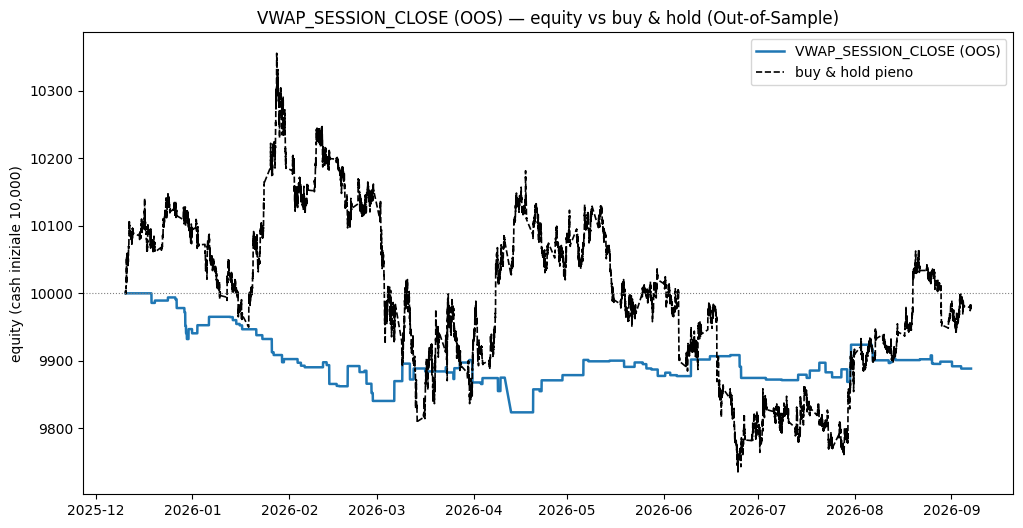

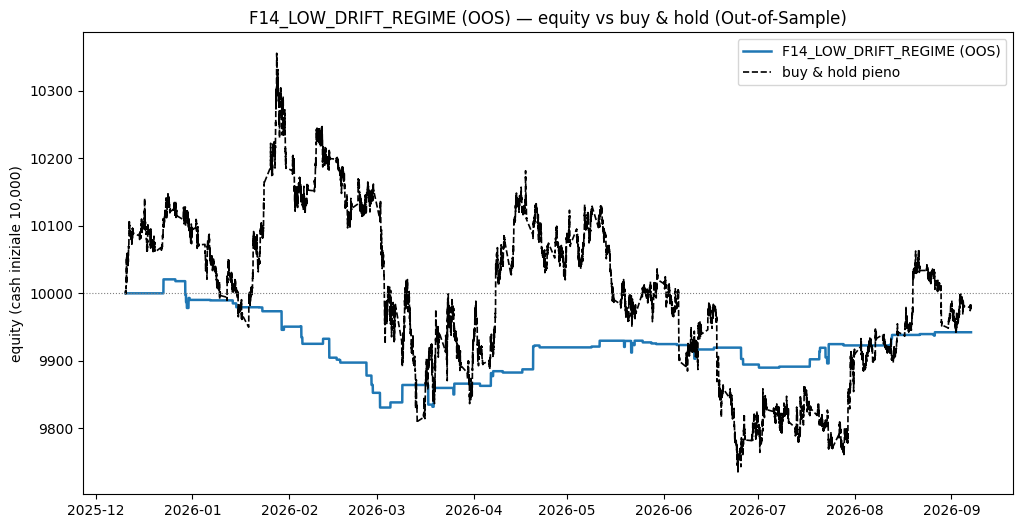

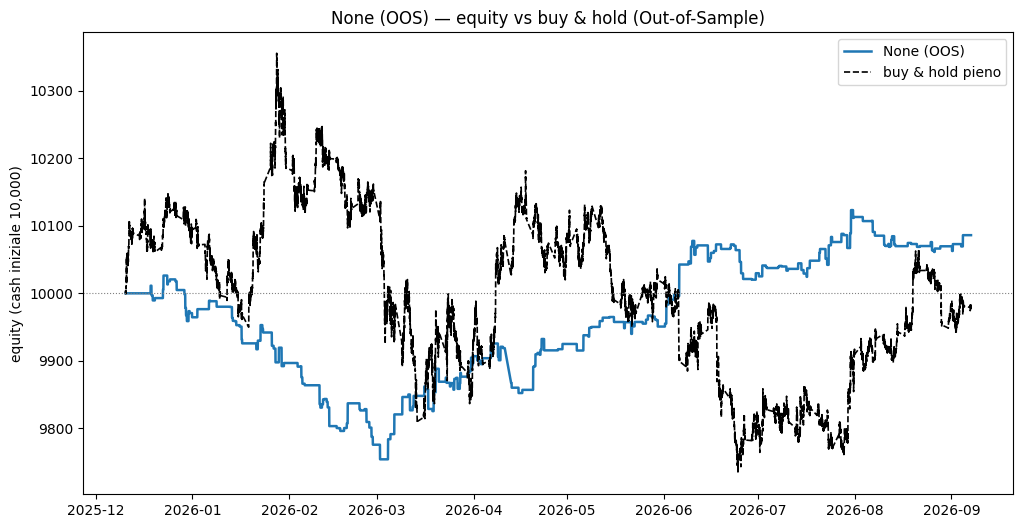

In [ ]:
for nome in ["VWAP_SESSION_CLOSE", "F14_LOW_DRIFT_REGIME", None]:
    ax, curva = plot_equity(oos.trades(nome), df_oos, cash=10_000.0,
                            etichetta=f"{nome} (OOS)")